In [67]:
import pandas as pd
import numpy as np

def reduce_memory_usage(df):
    start_mem = df.memory_usage(deep=True).sum() / 1024**2
    print(f"Initial memory usage: {start_mem:.2f} MB")

    for col in df.columns:
        col_type = df[col].dtypes

        if col_type == 'object':
            # Convert to category if few unique values
            num_unique = df[col].nunique()
            num_total = len(df[col])
            if num_unique / num_total < 0.5:
                df[col] = df[col].astype('category')

        elif pd.api.types.is_integer_dtype(df[col]):
            df[col] = pd.to_numeric(df[col], downcast='integer')

        elif pd.api.types.is_float_dtype(df[col]):
            df[col] = pd.to_numeric(df[col], downcast='float')

        elif pd.api.types.is_datetime64_any_dtype(df[col]):
            continue  # Already optimized

    end_mem = df.memory_usage(deep=True).sum() / 1024**2
    print(f"Reduced memory usage: {end_mem:.2f} MB")
    print(f"Reduction: {100 * (start_mem - end_mem) / start_mem:.1f}%")
    return df

In [4]:
import pandas as pd


add_trans = pd.read_parquet("add_trans.parquet")


add_trans.rename(columns={
    'id2': 'customer_id',
    'f370': 'date',
    'f371': 'time',
    'f372': 'year_month'
}, inplace=True)

add_trans['timestamp'] = pd.to_datetime(add_trans['date'] + ' ' + add_trans['time'], errors='coerce')


add_trans['year_month'] = pd.to_datetime(add_trans['year_month'].astype(str) + '01', format='%Y%m%d', errors='coerce')


add_trans.drop(['date', 'time'], axis=1, inplace=True)


add_trans.drop_duplicates(inplace=True)
add_trans.reset_index(drop=True, inplace=True)

add_trans['id8'] = add_trans['id8'].fillna('unknown')

add_trans['f367'] = add_trans['f367'].astype(float)
add_trans['f368'] = add_trans['f368'].astype('category')
add_trans['f369'] = add_trans['f369'].astype('category')
add_trans['f374'] = add_trans['f374'].astype('category')
add_trans['id8'] = add_trans['id8'].astype('string')

add_trans = reduce_memory_usage(add_trans)

#print(add_trans.head())
#print(add_trans.info())

add_trans.to_parquet('cleaned_add_trans.parquet', index=False)

Initial memory usage: 531.54 MB
Reduced memory usage: 531.54 MB
Reduction: 0.0%


In [5]:
add_event = pd.read_parquet("add_event.parquet")


add_event.rename(columns={
    'id2': 'customer_id',
    'id3': 'offer_id',
    'id4': 'event_timestamp',
    'id7': 'response_timestamp'
}, inplace=True)


add_event['event_timestamp'] = pd.to_datetime(add_event['event_timestamp'], errors='coerce')
add_event['response_timestamp'] = pd.to_datetime(add_event['response_timestamp'], errors='coerce')

add_event = add_event.dropna(subset=['event_timestamp'])


add_event.drop_duplicates(inplace=True)
add_event.reset_index(drop=True, inplace=True)

add_event['customer_id'] = add_event['customer_id'].astype('int32')
add_event['offer_id'] = add_event['offer_id'].astype('int32')
add_event['id6'] = add_event['id6'].astype('category')
 

add_event = reduce_memory_usage(add_event)


#print(add_event.info())
#print(add_event.head())

add_event.to_parquet("cleaned_add_event.parquet", index=False)

Initial memory usage: 511.59 MB
Reduced memory usage: 511.59 MB
Reduction: 0.0%


In [6]:
offer_metadata = pd.read_parquet("offer_metadata.parquet")

offer_metadata.rename(columns={
    'id3': 'offer_id',
    'id12': 'offer_startdate',
    'id13': 'offer_enddate',
    'f374': 'merchant_category',
    'id8':'merchant_category_code'
}, inplace=True)

offer_metadata['offer_startdate'] = pd.to_datetime(offer_metadata['offer_startdate'], errors='coerce')
offer_metadata['offer_enddate'] = pd.to_datetime(offer_metadata['offer_enddate'], errors='coerce')


for col in ['id9', 'merchant_category', 'merchant_category_code','id10','f378','f377','id11','f375','id10']:
    offer_metadata[col] = offer_metadata[col].astype('category')


# print(offer_metadata.info())
# print(offer_metadata.head())

offer_metadata.to_parquet("cleaned_offer_metadata.parquet", index=False)

In [17]:
import pandas as pd

train_data = pd.read_parquet("train_data.parquet")

train_data.rename(columns={
    'id3': 'offer_id',
    'id2': 'customer_id',
    'id4':'event_timestamp',
    'id5':'event_date'
}, inplace=True)

train_data.drop_duplicates(inplace=True)
train_data.reset_index(drop=True, inplace=True)

train_data['event_date'] = pd.to_datetime(train_data['event_date'], errors='coerce')

train_data = reduce_memory_usage(train_data)


print(train_data.info())
train_data.head()

Initial memory usage: 13009.92 MB
Reduced memory usage: 685.65 MB
Reduction: 94.7%
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 770164 entries, 0 to 770163
Columns: 372 entries, id1 to f366
dtypes: category(369), datetime64[ns](1), object(2)
memory usage: 502.6+ MB
None


,id1,customer_id,offer_id,event_timestamp,event_date,y,f1,f2,f3,f4,...,f357,f358,f359,f360,f361,f362,f363,f364,f365,f366
0,1366776_189706075_16-23_2023-11-02 22:22:00.042,1366776,189706075,2023-11-02 22:22:00.042,2023-11-02,0,1.0,NaN,NaN,NaN,...,NaN,-9999.0,0.0,NaN,28.0,0.0,0.0,337.0,0.0,0.0
1,1366776_89227_16-23_2023-11-01 23:51:24.999,1366776,89227,2023-11-01 23:51:24.999,2023-11-01,0,1.0,NaN,NaN,NaN,...,NaN,NaN,0.0,NaN,87.0,0.0,0.0,1010.0,2.0,0.0019801980198019
2,1366776_35046_16-23_2023-11-01 00:30:59.797,1366776,35046,2023-11-01 00:30:59.797,2023-11-01,0,1.0,NaN,NaN,NaN,...,NaN,NaN,0.0,NaN,23.0,0.0,0.0,1010.0,2.0,0.0019801980198019
3,1366776_6275451_16-23_2023-11-02 22:21:32.261,1366776,6275451,2023-11-02 22:21:32.261,2023-11-02,0,1.0,NaN,NaN,NaN,...,NaN,-9999.0,0.0,NaN,277.0,1.0,0.003610108303249,337.0,0.0,0.0
4,1366776_78053_16-23_2023-11-02 22:21:34.799,1366776,78053,2023-11-02 22:21:34.799,2023-11-02,0,1.0,NaN,NaN,NaN,...,NaN,-9999.0,0.0,NaN,359.0,0.0,0.0,337.0,0.0,0.0


In [68]:
import pandas as pd

test_data = pd.read_parquet("test_data.parquet")

test_data.rename(columns={
    'id3': 'offer_id',
    'id2': 'customer_id',
    'id4':'event_timestamp',
    'id5':'event_date'
}, inplace=True)

test_data.drop_duplicates(inplace=True)
test_data.reset_index(drop=True, inplace=True)

test_data['event_date'] = pd.to_datetime(test_data['event_date'], errors='coerce')

test_data = reduce_memory_usage(test_data)

test_data.to_parquet("cleaned_test_data.parquet", index=False)

print(test_data.info())
test_data.head()

Initial memory usage: 6376.55 MB
Reduced memory usage: 321.39 MB
Reduction: 95.0%
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 369301 entries, 0 to 369300
Columns: 371 entries, id1 to f366
dtypes: category(368), datetime64[ns](1), object(2)
memory usage: 231.2+ MB
None


,id1,customer_id,offer_id,event_timestamp,event_date,f1,f2,f3,f4,f5,...,f357,f358,f359,f360,f361,f362,f363,f364,f365,f366
0,1362907_91950_16-23_2023-11-04 18:56:26.000794,1362907,91950,2023-11-04 18:56:26.000794,2023-11-04,NaN,NaN,NaN,NaN,NaN,...,0.0027807272790246,0.0465999838670646,0.0,NaN,1.0,0.0,0.0,56.0,0.0,0.0
1,1082599_88356_16-23_2023-11-04 06:08:53.373,1082599,88356,2023-11-04 06:08:53.373,2023-11-04,NaN,9.0,NaN,NaN,NaN,...,0.0014287946777398,0.0603093514970909,0.0,NaN,195.0,13.0,0.0666666666666666,NaN,NaN,NaN
2,1888466_958700_16-23_2023-11-05 10:07:28.000725,1888466,958700,2023-11-05 10:07:28.000725,2023-11-05,NaN,NaN,NaN,NaN,22.0,...,-0.0174961119751166,0.0734836702954899,0.0,NaN,155.0,67.0,0.432258064516129,1142.0,436.0,0.3817863397548161
3,1888971_795739_16-23_2023-11-04 12:25:28.244,1888971,795739,2023-11-04 12:25:28.244,2023-11-04,NaN,NaN,NaN,NaN,NaN,...,0.0013159476327096,0.040572039549215,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1256369_82296_16-23_2023-11-05 06:45:26.657,1256369,82296,2023-11-05 06:45:26.657,2023-11-05,NaN,NaN,NaN,NaN,NaN,...,0.0020541699799278,0.038243539079214,0.0,NaN,29.0,2.0,0.0689655172413793,361.0,3.0,0.0083102493074792


In [19]:
train_data=pd.read_parquet('cleaned_train_data.parquet')
train_data.head()

,id1,customer_id,offer_id,event_timestamp,event_date,y,f1,f2,f3,f4,...,f357,f358,f359,f360,f361,f362,f363,f364,f365,f366
0,1366776_189706075_16-23_2023-11-02 22:22:00.042,1366776,189706075,2023-11-02 22:22:00.042,2023-11-02,0,1.0,NaN,NaN,NaN,...,NaN,-9999.0,0.0,NaN,28.0,0.0,0.0,337.0,0.0,0.0
1,1366776_89227_16-23_2023-11-01 23:51:24.999,1366776,89227,2023-11-01 23:51:24.999,2023-11-01,0,1.0,NaN,NaN,NaN,...,NaN,NaN,0.0,NaN,87.0,0.0,0.0,1010.0,2.0,0.0019801980198019
2,1366776_35046_16-23_2023-11-01 00:30:59.797,1366776,35046,2023-11-01 00:30:59.797,2023-11-01,0,1.0,NaN,NaN,NaN,...,NaN,NaN,0.0,NaN,23.0,0.0,0.0,1010.0,2.0,0.0019801980198019
3,1366776_6275451_16-23_2023-11-02 22:21:32.261,1366776,6275451,2023-11-02 22:21:32.261,2023-11-02,0,1.0,NaN,NaN,NaN,...,NaN,-9999.0,0.0,NaN,277.0,1.0,0.003610108303249,337.0,0.0,0.0
4,1366776_78053_16-23_2023-11-02 22:21:34.799,1366776,78053,2023-11-02 22:21:34.799,2023-11-02,0,1.0,NaN,NaN,NaN,...,NaN,-9999.0,0.0,NaN,359.0,0.0,0.0,337.0,0.0,0.0


In [26]:
add_event=pd.read_parquet('cleaned_add_event.parquet')

print(add_event['id6'].describe())
print(add_event['id6'].value_counts())
print(add_event['id6'].isnull().sum())

print(add_event['response_timestamp'].describe())
print(add_event['response_timestamp'].value_counts())
print(add_event['response_timestamp'].isnull().sum())

add_event.head()

count      21457473
unique            3
top       OffersTab
freq       11746928
Name: id6, dtype: object
id6
OffersTab          11746928
Tiles               7729729
Mobile_Timeline     1980816
Name: count, dtype: int64
0
count                           399090
mean     2023-10-29 11:00:47.441085440
min         2023-10-22 00:00:52.000293
25%      2023-10-26 05:11:07.000363264
50%      2023-10-30 06:46:53.500252416
75%      2023-11-01 16:30:40.750139392
max         2023-11-03 23:59:44.000178
Name: response_timestamp, dtype: object
response_timestamp
2023-10-28 00:27:45.000604    5
2023-10-28 00:27:45.000816    5
2023-11-01 10:48:21.000132    4
2023-10-28 00:27:45.000803    4
2023-10-28 00:27:45.000648    4
                             ..
2023-10-31 18:38:55.000971    1
2023-11-01 01:53:08.000213    1
2023-10-31 13:10:05.000128    1
2023-10-28 22:47:13.000245    1
2023-10-27 18:07:36.000255    1
Name: count, Length: 398756, dtype: int64
21058383


,customer_id,offer_id,id6,event_timestamp,response_timestamp
0,2431360,618619,Tiles,2023-10-22 08:08:17.768,NaT
1,2431360,363153,Tiles,2023-10-22 08:08:18.921,NaT
2,2431360,97193,Tiles,2023-10-22 08:08:17.765,NaT
3,2431360,654444,Tiles,2023-10-22 08:08:17.737,NaT
4,2431360,32325,Tiles,2023-10-22 08:08:17.812,NaT


In [28]:
add_trans=pd.read_parquet('cleaned_add_trans.parquet')

print(add_trans['f374'].describe())
print(add_trans['f374'].value_counts())
print(add_trans['f374'].isnull().sum())

print(add_trans['timestamp'].describe())
print(add_trans['timestamp'].value_counts())
print(add_trans['timestamp'].isnull().sum())

add_trans.head()

count     6261916
unique        532
top            EP
freq      1251634
Name: f374, dtype: object
f374
EP         1251634
BS          576121
GS          525854
GSS         356861
DS          216333
            ...   
CMAE             1
MB&P             1
MABWC            1
MABSCAO          1
CGN              1
Name: count, Length: 532, dtype: int64
0
count                          6261916
mean     2023-10-18 11:05:52.420166144
min                2023-10-02 00:00:00
25%                2023-10-10 00:00:00
50%                2023-10-18 12:11:00
75%      2023-10-26 20:09:53.249999872
max                2023-11-03 23:59:58
Name: timestamp, dtype: object
timestamp
2023-10-13 00:00:00    73138
2023-10-11 00:00:00    72660
2023-11-03 00:00:00    72305
2023-10-17 00:00:00    72049
2023-10-27 00:00:00    69991
                       ...  
2023-10-03 03:42:42        1
2023-11-01 07:39:16        1
2023-10-29 03:31:23        1
2023-10-29 08:11:42        1
2023-10-13 16:30:21        1
Name: count, L

,customer_id,f367,f368,f369,year_month,id8,f374,timestamp
0,2896709,15.60,PBR,D,2023-10-01,59639998,DSE,2023-10-16 19:16:52
1,2855047,6.40,PR,D,2023-10-01,59639998,DSE,2023-10-14 13:01:16
2,2497175,13.99,PBR,D,2023-10-01,59639998,DSE,2023-10-14 00:31:48
3,2655364,15.14,PGC,D,2023-10-01,59639998,DSE,2023-10-13 12:37:25
4,2855047,2.12,PR,D,2023-10-01,59639998,DSE,2023-10-09 16:51:21


In [30]:
offer_metadata=pd.read_parquet('cleaned_offer_metadata.parquet')

print(offer_metadata['id9'].describe())
print(offer_metadata['id9'].value_counts())
print(offer_metadata['id9'].isnull().sum())

print(offer_metadata['f378'].describe())
print(offer_metadata['f378'].value_counts())
print(offer_metadata['f378'].isnull().sum())

print(offer_metadata['merchant_category'].describe())
print(offer_metadata['merchant_category'].value_counts())
print(offer_metadata['merchant_category'].isnull().sum())

print(offer_metadata['merchant_category_code'].describe())
print(offer_metadata['merchant_category_code'].value_counts())
print(offer_metadata['merchant_category_code'].isnull().sum())

offer_metadata.head()

count     4164
unique    1614
top          A
freq        73
Name: id9, dtype: object
id9
A        73
M        68
B        67
S        66
D        52
         ..
JA-VB     1
JA-TL     1
JA-TA     1
JA-RN     1
Ａ         1
Name: count, Length: 1614, dtype: int64
0
count     4164
unique    1252
top          N
freq      2404
Name: f378, dtype: object
f378
N                                                             2404
gao$scbuyeectsamo$ioompoasb1st                                  17
gao$scbuyeectsamo$ioompoatb1st                                  15
ga$scbuyeebctsamo$ioomepfuamioob1lo3sc(o$st                     12
gao$scbuyeectsamo$ioompoamb1st                                  11
                                                              ... 
ga$scbuyeectmaspo$omoab8lo2sc(o$st                               1
ga$scbuyeectmaspo$omoabb1lo2sc(o$emapst                          1
ga$scbuyeectmaspo$omoabb1lo2sc(o$st                              1
ga$scbuyeectmaspo$omoabb3lo3sc(o$st        

,offer_id,id9,f375,f376,f377,id10,id11,f378,merchant_category,merchant_category_code,offer_startdate,offer_enddate
0,70687,FO5O,2,5.0,None,1,None,N,NaN,NaN,2018-01-01 00:00:00,2099-12-31 23:59:59
1,900002526,UGE,2,100.0,None,1,None,N,NaN,NaN,2014-10-20 00:00:00,2099-12-31 23:59:59
2,900002864,UTP,1,100.0,None,1,None,N,NaN,NaN,2016-07-19 00:00:00,2099-12-31 23:59:59
3,19508,o,2,NaN,None,1,None,N,NaN,NaN,2019-06-02 17:00:00,2028-12-31 16:59:59
4,35903,o,2,NaN,None,1,None,N,NaN,NaN,2019-06-02 17:00:00,2028-12-31 16:59:59


In [96]:
import pandas as pd

df=pd.read_parquet('cleaned_train_data.parquet')

ctr_cols = {
    "ctr_1d": "f310",
    "ctr_3d": "f311",
    "ctr_7d": "f312",
    "ctr_14d": "f313",
    "ctr_30d": "f314"
}

import numpy as np

ctr_cols = ["f310", "f311", "f312", "f313", "f314"]
for col in ctr_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Avoid division by 0 by adding a small epsilon
epsilon = 1e-6

df["ctr_ratio_1d_3d"] = df["f310"] / (df["f311"] + epsilon)
df["ctr_ratio_3d_7d"] = df["f311"] / (df["f312"] + epsilon)
df["ctr_ratio_7d_14d"] = df["f312"] / (df["f313"] + epsilon)
df["ctr_ratio_14d_30d"] = df["f313"] / (df["f314"] + epsilon)

# Assuming df is your train_data
ctr_cols = ["f310", "f311", "f312", "f313", "f314"]  # last 1d, 3d, 7d, 14d, 30d CTR


# Convert to numeric (force conversion and coerce errors to NaN)
df[ctr_cols] = df[ctr_cols].apply(pd.to_numeric, errors="coerce")


# 1. Average CTR across these periods
df["ctr_mean_1to30"] = df[ctr_cols].mean(axis=1)

# 2. Standard deviation (measures fluctuation)
df["ctr_std_1to30"] = df[ctr_cols].std(axis=1)

# 3. Max and min CTRs (to get range)
df["ctr_max_1to30"] = df[ctr_cols].max(axis=1)
df["ctr_min_1to30"] = df[ctr_cols].min(axis=1)
df["ctr_range_1to30"] = df["ctr_max_1to30"] - df["ctr_min_1to30"]

# 4. Is CTR increasing or decreasing over time?
df["ctr_trend_linear"] = df["f314"] - df["f310"]  # 30d - 1d



# Ratio of recent CTRs vs earlier ones
df["ctr_1d_vs_30d"] = df["f310"] / (df["f314"] + 1e-5)
df["ctr_3d_vs_30d"] = df["f311"] / (df["f314"] + 1e-5)
df["ctr_7d_vs_30d"] = df["f312"] / (df["f314"] + 1e-5)

# Volatility = standard deviation / mean
df["ctr_volatility"] = df["ctr_std_1to30"] / (df["ctr_mean_1to30"] + 1e-5)



merchant_ctr_cols = ["f336", "f337", "f338", "f339", "f340"]

for col in merchant_ctr_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')
    
# 1. Mean and std CTR on same-merchant offers
df["merchant_ctr_mean"] = df[merchant_ctr_cols].mean(axis=1)
df["merchant_ctr_std"] = df[merchant_ctr_cols].std(axis=1)

# 2. Trend
df["merchant_ctr_trend"] = df["f340"] - df["f336"]  # 30d - 1d

# 3. Volatility
df["merchant_ctr_volatility"] = df["merchant_ctr_std"] / (df["merchant_ctr_mean"] + 1e-5)



# Click & Impression columns
click_cols = ["f315", "f316", "f317", "f318", "f319"]
impr_cols = ["f320", "f321", "f322", "f323", "f324"]

# Convert to numeric (just in case)
df[click_cols] = df[click_cols].apply(pd.to_numeric, errors='coerce')
df[impr_cols] = df[impr_cols].apply(pd.to_numeric, errors='coerce')

# Aggregate stats
df["clicks_mean"] = df[click_cols].mean(axis=1)
df["clicks_std"] = df[click_cols].std(axis=1)
df["impr_mean"] = df[impr_cols].mean(axis=1)
df["impr_std"] = df[impr_cols].std(axis=1)

# Engagement ratios (last 1d click / impression)
epsilon = 1e-6
df["click_impr_ratio_1d"] = df["f315"] / (df["f320"] + epsilon)
df["click_impr_ratio_3d"] = df["f316"] / (df["f321"] + epsilon)
df["click_impr_ratio_7d"] = df["f317"] / (df["f322"] + epsilon)
df["click_impr_ratio_14d"] = df["f318"] / (df["f323"] + epsilon)
df["click_impr_ratio_30d"] = df["f319"] / (df["f324"] + epsilon)





In [98]:
df[["f351", "f352", "f353", "f354", "f355", "f356", "f357", "f358"]].dtypes

#these are categories, so change them to numericals.
# Convert all age & decay-related category features to numeric codes
age_decay_cols = ["f351", "f352", "f353", "f354", "f355", "f356", "f357", "f358"]

for col in age_decay_cols:
    df[col] = df[col].astype("category").cat.codes




In [100]:
#Convert f349 (Day of Week) to category or numeric
df["f349"] = df["f349"].astype("category").cat.codes

#Normalize f350 (Time of Day)
df["f350"] = df["f350"].astype(float) / 86400.0  # normalize to 0–1 range

In [103]:
#Convert categorical decay & age features to numeric
decay_cols = ["f351", "f352", "f353", "f354", "f355", "f356", "f357", "f358"]
df1[decay_cols] = df1[decay_cols].apply(lambda col: pd.to_numeric(col, errors="coerce"))

#Fill NaNs if any
df1[decay_cols] = df1[decay_cols].fillna(-1) 

In [104]:
#Financial Hardship Trigger Scores
df[["f359", "f360"]] = df[["f359", "f360"]].apply(pd.to_numeric, errors="coerce")
df[["f359", "f360"]] = df[["f359", "f360"]].fillna(-1)

# Industry CTR History for the CM (Customer Merchant)
df["f361"] = pd.to_numeric(df["f361"], errors="coerce")
df["f362"] = pd.to_numeric(df["f362"], errors="coerce")

epsilon = 1e-6
df["industry_ctr_calc"] = df["f362"] / (df["f361"] + epsilon)
df["industry_ctr_calc"] = df["f362"] / (df["f361"] + epsilon)

In [106]:
# Convert to numeric
df["f364"] = pd.to_numeric(df["f364"], errors="coerce")  # impressions
df["f365"] = pd.to_numeric(df["f365"], errors="coerce")  # clicks
df["f366"] = pd.to_numeric(df["f366"], errors="coerce")  # existing CTR

# Recalculate CTR
epsilon = 1e-6
df["ctr_6mo_calc"] = df["f365"] / (df["f364"] + epsilon)

# Optional: Difference between provided and calculated CTR
df["ctr_6mo_diff"] = df["f366"] - df["ctr_6mo_calc"]

In [109]:
# Category features (f226 to f232)
category_cols = [f"f{i}" for i in range(226, 233)]
df1["n_offer_categories"] = df1[category_cols].sum(axis=1)

# Subcategory features (f233 to f309)
subcategory_cols = [f"f{i}" for i in range(233, 310)]
df1["n_offer_subcategories"] = df1[subcategory_cols].sum(axis=1)

# Optional: flag if row has no category or subcategory
df1["no_offer_category"] = (df1["n_offer_categories"] == 0).astype(int)
df1["no_offer_subcategory"] = (df1["n_offer_subcategories"] == 0).astype(int)


# Ensure category/subcategory columns are binary 0/1
df1[category_cols] = df1[category_cols].apply(lambda col: col.cat.codes.replace(-1, 0))
df1[subcategory_cols] = df1[subcategory_cols].apply(lambda col: col.cat.codes.replace(-1, 0))

# Sum across category/subcategory flags
df1["n_offer_categories"] = df1[category_cols].sum(axis=1)
df1["n_offer_subcategories"] = df1[subcategory_cols].sum(axis=1)

# Recompute flags
df1["no_offer_category"] = (df1["n_offer_categories"] == 0).astype(int)
df1["no_offer_subcategory"] = (df1["n_offer_subcategories"] == 0).astype(int)

In [110]:
# Contextual features: time of day and day of week
df["is_weekend"] = df["f349"].isin([6, 7]).astype(int)
df["hour_of_day"] = (df["f350"] // 3600).astype(int)

# Optional: time buckets (morning, afternoon, etc.)
df["time_of_day_bucket"] = pd.cut(df["hour_of_day"],
                                  bins=[0, 6, 12, 18, 24],
                                  labels=["Night", "Morning", "Afternoon", "Evening"],
                                  right=False)

from sklearn.preprocessing import LabelEncoder
df["time_of_day_bucket_enc"] = LabelEncoder().fit_transform(df["time_of_day_bucket"])

/var/folders/kg/5fqjl4753r94_x_wqspmvr580000gn/T/ipykernel_25339/1219734344.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["is_weekend"] = df["f349"].isin([6, 7]).astype(int)
/var/folders/kg/5fqjl4753r94_x_wqspmvr580000gn/T/ipykernel_25339/1219734344.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["hour_of_day"] = (df["f350"] // 3600).astype(int)
/var/folders/kg/5fqjl4753r94_x_wqspmvr580000gn/T/ipykernel_25339/1219734344.py:6: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calli

In [112]:
drop_cols = [
    "customer_id", "offer_id",'id1',
    "event_timestamp", "event_date",
    "time_of_day_bucket", "f349", "f354"
]

# Raw CTR columns
ctr_cols = ["f310", "f311", "f312", "f313", "f314"]

# Raw click columns
click_cols = ["f315", "f316", "f317", "f318", "f319"]

# Raw impression columns
impr_cols = ["f320", "f321", "f322", "f323", "f324"]

# Merchant CTR columns if you used ratios/mean
merchant_ctr_cols = ["f336", "f337", "f338", "f339", "f340"]

# Drop them
df.drop(columns=ctr_cols + click_cols + impr_cols + merchant_ctr_cols, inplace=True)

# Drop columns with more than 90% missing
high_missing = df.columns[df.isnull().mean() > 0.9].tolist()

# Drop columns with only one unique value
constant_cols = df.columns[df.nunique(dropna=False) == 1].tolist()

# Drop them
df.drop(columns=high_missing + constant_cols, inplace=True)

print("High missing columns:", high_missing)
print("Constant columns:", constant_cols)

# Calculate correlation matrix (only numeric)
corr_matrix = df.select_dtypes(include=[float, int]).corr().abs()

# Upper triangle of correlation matrix
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

# Drop features with correlation > 0.95
to_drop = [column for column in upper.columns if any(upper[column] > 0.95)]

# Drop them
df.drop(columns=to_drop, inplace=True)

print("Highly correlated columns dropped:", to_drop)



High missing columns: ['f4', 'f13', 'f14', 'f15', 'f16', 'f17', 'f18', 'f19', 'f20', 'f21', 'f33', 'f34', 'f36', 'f37', 'f64', 'f66', 'f70', 'f79', 'f80', 'f81', 'f84', 'f88', 'f92', 'f112', 'f114', 'f117', 'f118', 'f120', 'f122', 'f135', 'f136', 'f154', 'f176', 'f189', 'f205', 'f220', 'f221']
Constant columns: ['f112', 'f122', 'f135', 'f136', 'f226', 'f229', 'f236', 'f238', 'f240', 'f243', 'f245', 'f246', 'f248', 'f249', 'f258', 'f259', 'f260', 'f262', 'f266', 'f267', 'f268', 'f270', 'f271', 'f277', 'f279', 'f281', 'f286', 'f287', 'f290', 'f291', 'f294', 'f295', 'f298', 'f300', 'f301', 'f303', 'f304', 'f307', 'f308', 'f309', 'is_weekend', 'hour_of_day', 'time_of_day_bucket', 'time_of_day_bucket_enc']
Highly correlated columns dropped: ['ctr_max_1to30', 'ctr_range_1to30', 'ctr_3d_vs_30d', 'impr_std', 'ctr_6mo_calc']


In [115]:
# Contextual features: time of day and day of week
df1["is_weekend"] = df1["f349"].isin([6, 7]).astype(int)
df1["hour_of_day"] = (df1["f350"] // 3600).astype(int)

# Optional: time buckets (morning, afternoon, etc.)
df1["time_of_day_bucket"] = pd.cut(df1["hour_of_day"],
                                  bins=[0, 6, 12, 18, 24],
                                  labels=["Night", "Morning", "Afternoon", "Evening"],
                                  right=False)

from sklearn.preprocessing import LabelEncoder
df1["time_of_day_bucket_enc"] = LabelEncoder().fit_transform(df1["time_of_day_bucket"])

df1.drop(columns=["time_of_day_bucket"], inplace=True)

In [116]:
# List of columns to drop
drop_cols = [
    # High missing columns
    'f4', 'f13', 'f14', 'f15', 'f16', 'f17', 'f18', 'f19', 'f20', 'f21',
    'f33', 'f34', 'f36', 'f37', 'f64', 'f66', 'f70', 'f79', 'f80', 'f81',
    'f84', 'f88', 'f92', 'f112', 'f114', 'f117', 'f118', 'f120', 'f122',
    'f135', 'f136', 'f154', 'f176', 'f189', 'f205', 'f220', 'f221',

    # Constant columns
    'f112', 'f122', 'f135', 'f136',

    # Previously dropped due to high correlation
    'ctr_max_1to30', 'ctr_range_1to30', 'ctr_3d_vs_30d', 'ctr_6mo_calc', 'no_offer_subcategory',

    # Identifier and datetime columns
    'customer_id', 'offer_id', 'event_timestamp', 'event_date','id1'
]

# Final model input (X) and target (y)
X = df.drop(columns=drop_cols + ['y'], errors='ignore')  # 'errors=ignore' in case any are already dropped
y = df['y']

In [118]:
# Recast to numeric in case dtype was not inferred properly
df["n_offer_categories"] = pd.to_numeric(df["n_offer_categories"], errors="coerce").fillna(0).astype(int)
df["n_offer_subcategories"] = pd.to_numeric(df["n_offer_subcategories"], errors="coerce").fillna(0).astype(int)

# Check for non-numeric columns in X_train
non_numeric_cols = X_train.select_dtypes(exclude=["int", "float", "bool"]).columns.tolist()
print("Non-numeric columns in training data:", non_numeric_cols)



Non-numeric columns in training data: ['id1', 'customer_id', 'offer_id', 'event_timestamp', 'event_date', 'f1', 'f2', 'f3', 'f5', 'f6', 'f7', 'f8', 'f9', 'f10', 'f11', 'f12', 'f22', 'f23', 'f24', 'f25', 'f26', 'f27', 'f28', 'f29', 'f30', 'f31', 'f32', 'f35', 'f38', 'f39', 'f40', 'f41', 'f42', 'f43', 'f44', 'f45', 'f46', 'f47', 'f48', 'f49', 'f50', 'f51', 'f52', 'f53', 'f54', 'f55', 'f56', 'f57', 'f58', 'f59', 'f60', 'f61', 'f62', 'f63', 'f65', 'f67', 'f68', 'f69', 'f71', 'f72', 'f73', 'f74', 'f75', 'f76', 'f77', 'f78', 'f82', 'f83', 'f85', 'f86', 'f87', 'f89', 'f90', 'f91', 'f93', 'f94', 'f95', 'f96', 'f97', 'f98', 'f99', 'f100', 'f101', 'f102', 'f103', 'f104', 'f105', 'f106', 'f107', 'f108', 'f109', 'f110', 'f111', 'f113', 'f115', 'f116', 'f119', 'f121', 'f123', 'f124', 'f125', 'f126', 'f127', 'f128', 'f129', 'f130', 'f131', 'f132', 'f133', 'f134', 'f137', 'f138', 'f139', 'f140', 'f141', 'f142', 'f143', 'f144', 'f145', 'f146', 'f147', 'f148', 'f149', 'f150', 'f151', 'f152', 'f153', 'f

In [120]:
df1.head()

,id1,customer_id,offer_id,event_timestamp,event_date,f1,f2,f3,f5,f6,...,click_impr_ratio_30d,industry_ctr_calc,ctr_6mo_diff,n_offer_categories,n_offer_subcategories,no_offer_category,no_offer_subcategory,is_weekend,hour_of_day,time_of_day_bucket_enc
0,1362907_91950_16-23_2023-11-04 18:56:26.000794,1362907,91950,2023-11-04 18:56:26.000794,2023-11-04,NaN,NaN,NaN,NaN,5.0,...,0.060357,0.000000,0.000000e+00,1,1,0,0,0,0,0
1,1082599_88356_16-23_2023-11-04 06:08:53.373,1082599,88356,2023-11-04 06:08:53.373,2023-11-04,NaN,9.0,NaN,NaN,NaN,...,0.058820,0.066667,NaN,1,1,0,0,0,0,0
2,1888466_958700_16-23_2023-11-05 10:07:28.000725,1888466,958700,2023-11-05 10:07:28.000725,2023-11-05,NaN,NaN,NaN,22.0,5.0,...,0.148886,0.432258,3.343138e-10,1,1,0,0,0,0,0
3,1888971_795739_16-23_2023-11-04 12:25:28.244,1888971,795739,2023-11-04 12:25:28.244,2023-11-04,NaN,NaN,NaN,NaN,NaN,...,0.046865,NaN,NaN,1,1,0,0,0,0,0
4,1256369_82296_16-23_2023-11-05 06:45:26.657,1256369,82296,2023-11-05 06:45:26.657,2023-11-05,NaN,NaN,NaN,NaN,NaN,...,0.046454,0.068966,2.302006e-11,1,1,0,0,0,0,0


In [28]:
!pip install lightgbm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 9.0 MB/s eta 0:00:00a 0:00:01


In [39]:

from sklearn.model_selection import train_test_split

# Initial 85% split: train + validation/test
X_temp, X_holdout, y_temp, y_holdout = train_test_split(
    X, y, test_size=0.15, stratify=y, random_state=42
)

# Final split: train (70%) and validation (15%)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.1765, stratify=y_temp, random_state=42  # 0.1765 ≈ 15/85
)




# Convert all object columns to numeric
object_cols = X_train.select_dtypes(include=["object", "category"]).columns

# Option 1: Convert with `pd.to_numeric`, forcing errors to NaN
for col in object_cols:
    X_train[col] = pd.to_numeric(X_train[col], errors='coerce')
    X_val[col] = pd.to_numeric(X_val[col], errors='coerce')
    X_holdout[col] = pd.to_numeric(X_holdout[col], errors='coerce')  # If you're using holdout set

# Optionally fill remaining NaNs (use your strategy here — mean/median/etc.)
X_train = X_train.fillna(0)
X_val = X_val.fillna(0)
X_holdout = X_holdout.fillna(0)


In [41]:
# Convert y to numeric (if it's categorical)
y_train = y_train.astype(int)
y_val = y_val.astype(int)
y_holdout = y_holdout.astype(int)  # If you're using it

In [46]:


import lightgbm as lgb
from sklearn.metrics import roc_auc_score


# Create LightGBM dataset
dtrain = lgb.Dataset(X_train, label=y_train)
dval = lgb.Dataset(X_val, label=y_val, reference=dtrain)

# Basic parameters (we can tune later)
params = {
    "objective": "binary",
    "metric": "auc",
    "verbosity": -1,
    "boosting_type": "gbdt",
    "learning_rate": 0.05,
    "num_leaves": 31,
    "seed": 42
}

# Train model with early stopping

from lightgbm import early_stopping, log_evaluation, record_evaluation

evals_result = {}  # dictionary to store results

model = lgb.train(
    params,
    dtrain,
    valid_sets=[dtrain, dval],
    valid_names=["train", "val"],
    num_boost_round=1000,
    callbacks=[
        early_stopping(stopping_rounds=50),
        log_evaluation(period=100),
        record_evaluation(evals_result)  # <--- THIS captures eval results
    ]
)

Training until validation scores don't improve for 50 rounds
[100]	train's auc: 0.94592	val's auc: 0.94168
[200]	train's auc: 0.957981	val's auc: 0.94835
[300]	train's auc: 0.966315	val's auc: 0.950825
[400]	train's auc: 0.972578	val's auc: 0.95215
[500]	train's auc: 0.976946	val's auc: 0.95304
[600]	train's auc: 0.980716	val's auc: 0.953654
[700]	train's auc: 0.983521	val's auc: 0.954021
[800]	train's auc: 0.985917	val's auc: 0.954364
[900]	train's auc: 0.98793	val's auc: 0.954751
[1000]	train's auc: 0.989442	val's auc: 0.954938
Did not meet early stopping. Best iteration is:
[984]	train's auc: 0.989241	val's auc: 0.954941


In [47]:
# Save model to file
model.save_model("lgb_model.txt")

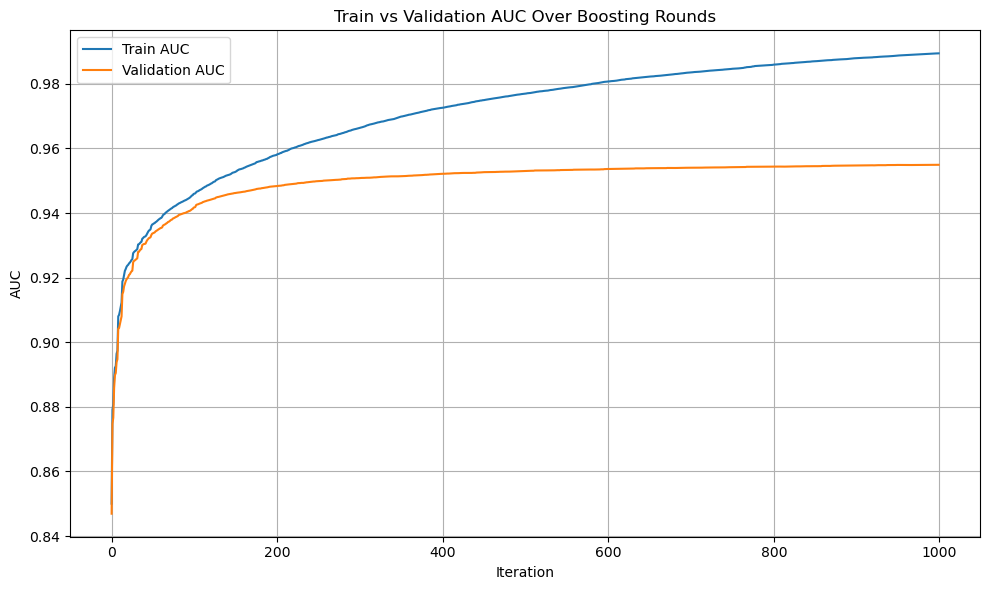

In [50]:
import matplotlib.pyplot as plt

# No need to access model.evals_result_ — we already have evals_result from the callback
plt.figure(figsize=(10, 6))
plt.plot(evals_result['train']['auc'], label='Train AUC')
plt.plot(evals_result['val']['auc'], label='Validation AUC')
plt.xlabel('Iteration')
plt.ylabel('AUC')
plt.title('Train vs Validation AUC Over Boosting Rounds')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [121]:
X['n_offer_categories'] = X['n_offer_categories'].astype('category')
X['n_offer_subcategories'] = X['n_offer_subcategories'].astype('category')

In [59]:
import pandas as pd
import numpy as np
import lightgbm as lgb
import datetime
import os
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score

# === Configuration ===
TARGET = 'clicked'
N_SPLITS = 5
SEED = 42
LOG_PATH = 'cv_log.csv'
MAX_ROUNDS = 5000
EARLY_STOP = 100

# === Data ===
# X, y should already be defined and cleaned
# For example:
# X = train_data.drop(columns=[TARGET])
# y = train_data[TARGET]

# === Parameters ===
params = {
    "objective": "binary",
    "metric": "auc",
    "boosting_type": "gbdt",
    "learning_rate": 0.03,
    "num_leaves": 64,
    "feature_fraction": 0.8,
    "bagging_fraction": 0.8,
    "bagging_freq": 5,
    "lambda_l1": 1.0,
    "lambda_l2": 1.0,
    "verbosity": -1,
    "seed": SEED
}

# === Cross-validation ===
kf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)

val_auc_scores = []
train_auc_scores = []
best_iterations = []
fold = 0

for train_idx, val_idx in kf.split(X, y):
    print(f"\n🔁 Fold {fold+1}/{N_SPLITS}")
    
    X_train, y_train = X.iloc[train_idx], y.iloc[train_idx]
    X_val, y_val = X.iloc[val_idx], y.iloc[val_idx]

    y_train = y_train.astype(int)
    y_val = y_val.astype(int)

    lgb_train = lgb.Dataset(X_train, y_train)
    lgb_val = lgb.Dataset(X_val, y_val, reference=lgb_train)

    model = lgb.train(
        {**params, "seed": SEED + fold},
        lgb_train,
        num_boost_round=MAX_ROUNDS,
        valid_sets=[lgb_train, lgb_val],
        valid_names=["train", "val"],
        callbacks=[lgb.early_stopping(EARLY_STOP), lgb.log_evaluation(200)]
    )

    y_train_pred = model.predict(X_train, num_iteration=model.best_iteration)
    y_val_pred = model.predict(X_val, num_iteration=model.best_iteration)

    train_auc = roc_auc_score(y_train, y_train_pred)
    val_auc = roc_auc_score(y_val, y_val_pred)

    train_auc_scores.append(train_auc)
    val_auc_scores.append(val_auc)
    best_iterations.append(model.best_iteration)

    print(f"✅ Fold {fold+1} done: Train AUC = {train_auc:.4f}, Val AUC = {val_auc:.4f}")
    fold += 1

# === Summary ===
overall_auc = np.mean(val_auc_scores)
print(f"\n📊 Overall CV AUC = {overall_auc:.5f}")

# === Logging ===
log_df = pd.DataFrame({
    'fold': list(range(N_SPLITS)),
    'train_auc': train_auc_scores,
    'val_auc': val_auc_scores,
    'best_iteration': best_iterations,
    'train_size': [len(train_idx) for train_idx, _ in kf.split(X, y)],
    'val_size': [len(val_idx) for _, val_idx in kf.split(X, y)],
    'timestamp': pd.Timestamp.now(),
    'params': [params] * N_SPLITS
})
log_df.to_csv(LOG_PATH, index=False, mode='a', header=not os.path.exists(LOG_PATH))

# Optionally log summary
summary_log = {
    'timestamp': datetime.datetime.now().strftime('%Y-%m-%d %H:%M:%S'),
    'model': 'LightGBM',
    'n_splits': N_SPLITS,
    'overall_auc': overall_auc,
    'fold_aucs': val_auc_scores,
    'train_aucs': train_auc_scores,
    'best_iterations': best_iterations,
    'params': str(params),
    'comment': "Baseline with CV + L1/L2 regularization"
}
pd.DataFrame([summary_log]).to_csv("cv_summary.csv", mode='a', index=False, header=not os.path.exists("cv_summary.csv"))


🔁 Fold 1/5
Training until validation scores don't improve for 100 rounds
[200]	train's auc: 0.992658	val's auc: 0.956639
Early stopping, best iteration is:
[180]	train's auc: 0.991661	val's auc: 0.956684
✅ Fold 1 done: Train AUC = 0.9917, Val AUC = 0.9567

🔁 Fold 2/5
Training until validation scores don't improve for 100 rounds
[200]	train's auc: 0.992644	val's auc: 0.954687
Early stopping, best iteration is:
[168]	train's auc: 0.990997	val's auc: 0.954883
✅ Fold 2 done: Train AUC = 0.9910, Val AUC = 0.9549

🔁 Fold 3/5
Training until validation scores don't improve for 100 rounds
[200]	train's auc: 0.992574	val's auc: 0.957027
Early stopping, best iteration is:
[181]	train's auc: 0.991667	val's auc: 0.957151
✅ Fold 3 done: Train AUC = 0.9917, Val AUC = 0.9572

🔁 Fold 4/5
Training until validation scores don't improve for 100 rounds
[200]	train's auc: 0.99261	val's auc: 0.956656
Early stopping, best iteration is:
[160]	train's auc: 0.990377	val's auc: 0.956819
✅ Fold 4 done: Train AUC 

In [60]:
for i in range(N_SPLITS):
    print(f"Fold {i+1}: Train AUC = {train_auc_scores[i]:.4f}, Val AUC = {val_auc_scores[i]:.4f}, Best Iter = {best_iterations[i]}")
print(f"\n📊 Mean Val AUC: {np.mean(val_auc_scores):.5f}")

Fold 1: Train AUC = 0.9917, Val AUC = 0.9567, Best Iter = 180
Fold 2: Train AUC = 0.9910, Val AUC = 0.9549, Best Iter = 168
Fold 3: Train AUC = 0.9917, Val AUC = 0.9572, Best Iter = 181
Fold 4: Train AUC = 0.9904, Val AUC = 0.9568, Best Iter = 160
Fold 5: Train AUC = 0.9900, Val AUC = 0.9534, Best Iter = 149

📊 Mean Val AUC: 0.95579


In [63]:
import pandas as pd
pd.read_csv("cv_log.csv")

,fold,train_auc,val_auc,best_iteration,train_size,val_size,timestamp,params
0,0,0.991661,0.956684,180,616131,154033,2025-07-18 00:24:10.416029,"{'objective': 'binary', 'metric': 'auc', 'boos..."
1,1,0.990997,0.954883,168,616131,154033,2025-07-18 00:24:10.416029,"{'objective': 'binary', 'metric': 'auc', 'boos..."
2,2,0.991667,0.957151,181,616131,154033,2025-07-18 00:24:10.416029,"{'objective': 'binary', 'metric': 'auc', 'boos..."
3,3,0.990377,0.956819,160,616131,154033,2025-07-18 00:24:10.416029,"{'objective': 'binary', 'metric': 'auc', 'boos..."
4,4,0.989961,0.953423,149,616132,154032,2025-07-18 00:24:10.416029,"{'objective': 'binary', 'metric': 'auc', 'boos..."


In [125]:
# === Data ===
# Assume your cleaned train and test are loaded as train_df, test_df

# 🔻 OPTION 1: Drop same columns from train and test
cols_to_drop = [
    'f4', 'f13', 'f14', 'f15', 'f16', 'f17', 'f18', 'f19', 'f20', 'f21',
    'f33', 'f34', 'f36', 'f37', 'f64', 'f66', 'f70', 'f79', 'f80', 'f81', 'f84', 'f88', 'f92', 'f112', 'f114',
    'f117', 'f118', 'f120', 'f122', 'f135', 'f136', 'f154', 'f176', 'f189', 'f205', 'f220', 'f221',
    'f226', 'f229', 'f236', 'f238', 'f240', 'f243', 'f245', 'f246', 'f248', 'f249', 'f258', 'f259',
    'f260', 'f262', 'f266', 'f267', 'f268', 'f270', 'f271', 'f277', 'f279', 'f281', 'f286', 'f287',
    'f290', 'f291', 'f294', 'f295', 'f298', 'f300', 'f301', 'f303', 'f304', 'f307', 'f308', 'f309',
    'ctr_max_1to30', 'ctr_range_1to30', 'impr_std', 'click_impr_ratio_7d', 'ctr_6mo_calc',
    'is_weekend', 'hour_of_day', 'time_of_day_bucket', 'time_of_day_bucket_enc','id1','event_timestamp', 'event_date'
]

df.drop(columns=cols_to_drop, inplace=True, errors='ignore')
df1.drop(columns=cols_to_drop, inplace=True, errors='ignore')

target='y'
# 🧷 Now define X and y
X = df.drop(columns=[target])
y = df[target]

In [130]:
import lightgbm as lgb

lgb_params = {
    'objective': 'binary',
    'boosting_type': 'gbdt',
    'metric': 'auc',
    'learning_rate': 0.05,
    'num_leaves': 31,
    'max_depth': -1,
    'feature_fraction': 0.8,
    'bagging_fraction': 0.8,
    'bagging_freq': 5,
    'verbose': -1,
    'n_jobs': -1,
    'random_state': 42,
}

y = y.astype(int)

In [131]:
# Train on full data with average number of boosting rounds from CV
final_model = lgb.train(
    lgb_params,
    lgb.Dataset(X, y),
    num_boost_round=int(np.mean(best_iterations))  # or just use 160–180 if unsure
)

In [147]:
import pandas as pd

# Load test data (adjust filename as needed)
df2 = pd.read_parquet("test_data.parquet")

# Predict using model
X_test = df1[X_train.columns]
df2["pred"] = final_model.predict(X_test, num_iteration=final_model.best_iteration)

# Reuse existing id1 from test data
submission_df = df2[["id1", "id2", "id3", "id5", "pred"]]
submission_df.columns = ["id1", "id2", "id3", "id5", "pred"]


# Save final submission
submission_df.to_csv("submission.csv", index=False)

In [148]:
# Sort submission by id1
submission_df = submission_df.sort_values("id1").reset_index(drop=True)

# Save to CSV
submission_df.to_csv("final_submission.csv", index=False)

submission_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 369301 entries, 0 to 369300
Data columns (total 5 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   id1     369301 non-null  object 
 1   id2     369301 non-null  object 
 2   id3     369301 non-null  object 
 3   id5     369301 non-null  object 
 4   pred    369301 non-null  float64
dtypes: float64(1), object(4)
memory usage: 14.1+ MB


In [149]:
test_data_df=pd.read_parquet('test_data.parquet')

test_data_df= test_data_df.sort_values("id1").reset_index(drop=True)

# Save to CSV
test_data_df.to_csv("order_test_data.csv", index=False)

In [151]:
test_data_df

,id1,id2,id3,id4,id5,f1,f2,f3,f4,f5,...,f357,f358,f359,f360,f361,f362,f363,f364,f365,f366
0,1000061_16099_16-23_2023-11-05 09:28:11.514,1000061,16099,2023-11-05 09:28:11.514,2023-11-05,None,None,None,None,None,...,0.0020074926733205,0.0418442166685861,None,None,None,None,None,None,None,None
1,1000061_1802_16-23_2023-11-05 09:47:54.545,1000061,1802,2023-11-05 09:47:54.545,2023-11-05,None,None,None,None,None,...,0.0020838805779419,0.0618616619183111,None,None,None,None,None,None,None,None
2,1000061_187169_16-23_2023-11-05 09:28:11.783,1000061,187169,2023-11-05 09:28:11.783,2023-11-05,None,None,None,None,None,...,0.0018402745008282,0.04861296600145,None,None,None,None,None,None,None,None
3,1000061_23690_16-23_2023-11-05 09:11:36.193,1000061,23690,2023-11-05 09:11:36.193,2023-11-05,None,None,None,None,None,...,0.0021261675323,0.0432219873506913,None,None,None,None,None,None,None,None
4,1000061_25086_16-23_2023-11-05 09:28:07.945,1000061,25086,2023-11-05 09:28:07.945,2023-11-05,None,None,None,None,None,...,0.0010140632566211,0.0481267538904479,None,None,None,None,None,None,None,None
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
369296,1910523_57342_16-23_2023-11-04 08:24:17.804,1910523,57342,2023-11-04 08:24:17.804,2023-11-04,49.0,49.0,None,None,100.0,...,0.0041607707026281,0.0528956522470351,0.0,None,12.0,0.0,0.0,146.0,0.0,0.0
369297,1910523_65430_16-23_2023-11-04 08:24:17.803,1910523,65430,2023-11-04 08:24:17.803,2023-11-04,49.0,49.0,None,None,100.0,...,-0.014841072905589,0.0623325062034739,0.0,None,2.0,0.0,0.0,325.0,0.0,0.0
369298,1910523_65699008_16-23_2023-11-05 06:26:41.492,1910523,65699008,2023-11-05 06:26:41.492,2023-11-05,49.0,49.0,None,None,100.0,...,-0.0119335869941196,0.0501210653753026,0.0,None,4.0,0.0,0.0,90.0,0.0,0.0
369299,1910523_735023_16-23_2023-11-05 06:26:42.053,1910523,735023,2023-11-05 06:26:42.053,2023-11-05,49.0,49.0,None,None,100.0,...,-0.0116119707956442,0.0487702773417059,0.0,None,6.0,0.0,0.0,90.0,0.0,0.0


In [159]:
import pandas as pd
import lightgbm as lgb

# 1. Load test data
df2 = pd.read_parquet("cleaned_test_data.parquet")

# 2. Load your trained model's features (assumes you have df1 and X_train from training)
X_test = df2[X_train.columns]

# 3. Predict using final model
df2["pred"] = final_model.predict(X_test, num_iteration=final_model.best_iteration)

# 4. Load submission template
submission_template = pd.read_csv("submission_template.csv")

# 5. Optional: Sort both to align predictions safely (only needed if row order might mismatch)
df2 = df2.sort_values(["id1", "id2", "id3", "id5"]).reset_index(drop=True)
submission_template = submission_template.sort_values(["id1", "id2", "id3", "id5"]).reset_index(drop=True)

# 6. Sanity check
assert len(df2) == len(submission_template), "Mismatch in number of rows between prediction and template"

# 7. Assign predictions safely (ignoring index)
submission_template["pred"] = df2["pred"].values

# 8. Save final submission
submission_template.to_csv("final_submission(2).csv", index=False)

print("✅ Final submission file saved as 'final_submission.csv'")

KeyError: "['ctr_ratio_1d_3d', 'ctr_ratio_3d_7d', 'ctr_ratio_7d_14d', 'ctr_ratio_14d_30d', 'ctr_mean_1to30', 'ctr_std_1to30', 'ctr_min_1to30', 'ctr_trend_linear', 'ctr_1d_vs_30d', 'ctr_7d_vs_30d', 'ctr_volatility', 'merchant_ctr_mean', 'merchant_ctr_std', 'merchant_ctr_trend', 'merchant_ctr_volatility', 'clicks_mean', 'clicks_std', 'impr_mean', 'click_impr_ratio_1d', 'click_impr_ratio_3d', 'click_impr_ratio_14d', 'click_impr_ratio_30d', 'industry_ctr_calc', 'ctr_6mo_diff', 'n_offer_categories', 'n_offer_subcategories', 'no_offer_category', 'no_offer_subcategory'] not in index"